# ==========================================
#  Deliverables: Requirements Installation 1
# ==========================================

In [ ]:
!pip install -qU pymilvus transformers sentence-transformers datasets rouge_score nltk accelerate bitsandbytes

## 1. Data Cleaning and Preprocessing
In this section, we download the raw text of the book from Project Gutenberg and clean the unnecessary boilerplate components (license text, headers, and footers) to reduce noise in our vector database. Then, we fetch the `deepmind/narrativeqa` dataset and filter it to extract only the 116 question-answer pairs relevant to our specific book. We encapsulate this logic inside a `DataPreprocessor` class to maintain modularity and clean code architecture.

In [ ]:
import urllib.request
import re
from datasets import load_dataset
import nltk

# for BLEU NLTK packages
nltk.download('punkt')
nltk.download('punkt_tab')

class DataPreprocessor:
    """
    A class to handle the downloading, cleaning, and preparation of the raw book text
    and the corresponding QA dataset for the RAG pipeline.
    """
    def __init__(self, book_url):
        self.book_url = book_url
        self.raw_text = ""
        self.cleaned_text = ""
        self.qa_pairs = []

    def download_book(self):
        """
        Downloads the raw UTF-8 text of the book from Project Gutenberg.
        """
        print("Gutenberg book downloading...")
        response = urllib.request.urlopen(self.book_url)
        self.raw_text = response.read().decode('utf-8')
        print(f"The book has been downloaded. Total characters: {len(self.raw_text)}")

    def clean_gutenberg_text(self):
        """
        Cleans the downloaded text by removing Gutenberg legal headers and footers.
        Also normalizes excessive newlines to prevent chunking issues.
        """
        print("Text is cleaning...")

        # Markers indicating the actual start and end of the book content
        start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
        end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

        start_idx = self.raw_text.find(start_marker)
        end_idx = self.raw_text.find(end_marker)

        # Exclude the header line itself
        if start_idx != -1:
            start_idx = self.raw_text.find('\n', start_idx) + 1
        else:
            start_idx = 0

        if end_idx == -1:
            end_idx = len(self.raw_text)

        text = self.raw_text[start_idx:end_idx]

        # Regex: Replace 3 or more consecutive newlines with just 2 newlines
        # This keeps paragraph breaks but removes huge empty gaps
        text = re.sub(r'\n{3,}', '\n\n', text)
        self.cleaned_text = text.strip()
        print(f"Number of cleaned text characters: {len(self.cleaned_text)}")
        return self.cleaned_text

    def load_qa_dataset(self):
        """
        Downloads the NarrativeQA dataset and filters the questions based on the target book URL.
        """
        print("QA Dataset downloading...")

        # Load only the test split to save memory and time
        dataset = load_dataset("deepmind/narrativeqa", split="test")

        # Iterate through the dataset and match the document URL with our book's Gutenberg ID (47)
        for item in dataset:
            if "gutenberg.org/ebooks/47" in item.get('document', {}).get('url', ''):
                 self.qa_pairs.append({
                     "question": item['document']['summary']['text'],
                     "answers": [ans['text'] for ans in item['answers']]
                 })

        print("QA Dataset uploaded.")

        print(f"Number of question-answer pairs found: {len(self.qa_pairs)}")


# EXECUTION
book_url = "https://www.gutenberg.org/cache/epub/47/pg47.txt"
preprocessor = DataPreprocessor(book_url)

preprocessor.download_book()
clean_text = preprocessor.clean_gutenberg_text()
preprocessor.load_qa_dataset()

print("\n--- Data preparation is complete. ---")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Gutenberg book downloading...
The book has been downloaded. Total characters: 517539
Text is cleaning...
Number of cleaned text characters: 497859
QA Dataset downloading...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

QA Dataset uploaded.
Number of question-answer pairs found: 116

--- Data preparation is complete. ---


## 2. Chunking Strategies and Embedding Model Generation
In this section, we implement the two required chunking methodologies to compare their impact on RAG performance.
1. **Fixed-Size Character-Based Chunking**: Slices the text into strict character windows regardless of linguistic boundaries.
2. **Sentence-Based Chunking**: Tokenizes the text into sentences first using NLTK, ensuring semantic boundaries are preserved.
After chunking, we initialize the mandatory `BAAI/bge-small-en-v1.5` embedding model to transform our text passages into 384-dimensional dense vectors for vector database ingestion.

In [ ]:
import nltk
from sentence_transformers import SentenceTransformer

# Ensure tokenization resources are available
nltk.download('punkt')
nltk.download('punkt_tab')

"""
    A class responsible for splitting long text documents into smaller,
    manageable fragments (chunks) using different algorithmic approaches.
"""
class TextChunker:
    def __init__(self, text):
        self.text = text

    def fixed_size_chunking(self, chunk_size=800, overlap=100):
        """
        Splits text by character count. Swift and simple, but might cut sentences in half.
        """

        print("Fixed size chunking process has been initiated...")
        chunks = []

        # Slide the window across the text with a step size of (chunk_size - overlap)
        for i in range(0, len(self.text), chunk_size - overlap):
            chunk = self.text[i:i + chunk_size]
            if len(chunk.strip()) > 50: # Ignore tiny fragments at the very end of the file to maintain data quality
                chunks.append(chunk.strip())
        return chunks

    def sentence_based_chunking(self, chunk_size_in_sentences=8, overlap=2):
        """
        Splits text by tracking actual sentence boundaries using NLP tokenizers.
        """

        print("Sentence based chunking process initiated...")
        # Use NLTK to split the book into a list of complete sentences
        sentences = nltk.sent_tokenize(self.text)
        chunks = []

        # Group sentences into windows with the specified overlap
        for i in range(0, len(sentences), chunk_size_in_sentences - overlap):
            chunk_sentences = sentences[i:i + chunk_size_in_sentences]
            chunk = " ".join(chunk_sentences)
            if len(chunk.strip()) > 50:
                chunks.append(chunk.strip())
        return chunks

#Chunking Process
chunker = TextChunker(clean_text)

# Execute both strategies using optimized hyperparameters
fixed_chunks = chunker.fixed_size_chunking(chunk_size=250, overlap=50)
sentence_chunks = chunker.sentence_based_chunking(chunk_size_in_sentences=8, overlap=2)

print(f"\nFixed Number of Chunks Created: {len(fixed_chunks)}")
print(f"Sentence Based Number of Chunks Created: {len(sentence_chunks)}")

#Embedding Model Loading
print("\nBAAI/bge-small-en-v1.5 Loading embedding model...")
embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

#Test => calculating embedding of the first chunk and  see its size
sample_embedding = embedding_model.encode(sentence_chunks[0])
print(f"Embedding created successfully. Vektör boyutu: {len(sample_embedding)}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Fixed size chunking process has been initiated...
Sentence based chunking process initiated...

Fixed Number of Chunks Created: 2490
Sentence Based Number of Chunks Created: 1114

BAAI/bge-small-en-v1.5 Loading embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding created successfully. Vektör boyutu: 384


# ==========================================
#  Deliverables: Requirements Installation 2
# ==========================================

In [ ]:
!pip install -qU "pymilvus[milvus_lite]"

## 3. Vector Database Ingestion with Milvus Lite
To efficiently store and query our high-dimensional embeddings, we leverage Milvus Lite, a lightweight, file-based version of the Milvus vector database that runs natively within our notebook environment.
We design an idempotent insertion pipeline that ensures repeatability: if the collection already exists, it is safely dropped before recreating it. This guarantees that multiple executions of this notebook yield consistent data without duplicates. We process embeddings in batches to exploit parallel GPU computation, dramatically accelerating the ingestion of both chunking strategies.

In [ ]:
from pymilvus import MilvusClient
import numpy as np

# Launch Milvus Lite as a local file-backed instance inside the project environment
print("Milvus database is being launched....")
client = MilvusClient("rag_project_v2.db")


def create_and_insert_collection(collection_name, chunks, embedding_model):
    """
    Creates a new collection in Milvus, computes embeddings in batches,
    and inserts the structural data (ID, Vector, Context Text) into the database.
    """
    print(f"\n'{collection_name}' collection (table) is being prepared....")

    # Repeatability Check=> If the collection exists from a previous run, drop it
    # This prevents primary key conflicts and ensures reproducible results
    if client.has_collection(collection_name):
        client.drop_collection(collection_name)

    # Initialize the collection schema with the precise vector output dimensionality
    client.create_collection(
        collection_name=collection_name,
        dimension=384 # Matches the output space of BAAI/bge-small-en-v1.5
    )

    # convert the data into a format that Milvus understands
    data = []
    print("Embeddings are being calculated....")

    # Optimization=>Perform batch-encoding across all chunks simultaneously
    # to maximize hardware acceleration (GPU/CPU vector operations)
    embeddings = embedding_model.encode(chunks)

    # Format data records into structural JSON-like dictionaries required by Milvus
    for i, (chunk, emb) in enumerate(zip(chunks, embeddings)):
        data.append({
            "id": i,
            "vector": emb.tolist(), # convert Numpy array to a standard Python list
            "text": chunk           # saving original text so LLM can read
        })

    # Bulk insert the formatted payloads into Milvus
    res = client.insert(collection_name=collection_name, data=data)
    print(f"Successfull! {res['insert_count']} number of pieces '{collection_name}' uploaded to collection.")

#DATABASE INGESTION EXECUTION

create_and_insert_collection("fixed_chunks_collection", fixed_chunks, embedding_model)
create_and_insert_collection("sentence_chunks_collection", sentence_chunks, embedding_model)

print("\n--- Milvus Database Installation Complete ---")

Milvus database is being launched....

'fixed_chunks_collection' collection (table) is being prepared....
Embeddings are being calculated....
Successfull! 2490 number of pieces 'fixed_chunks_collection' uploaded to collection.

'sentence_chunks_collection' collection (table) is being prepared....
Embeddings are being calculated....
Successfull! 1114 number of pieces 'sentence_chunks_collection' uploaded to collection.

--- Milvus Database Installation Complete ---


## 4. Vector Search and Information Retrieval Verification
Before building the final generation pipeline, we verify our retrieval component by executing a sample semantic search query. We look for *"Who is Matthew Cuthbert?"* inside our `sentence_chunks_collection`.
The query text is embedded using the exact same embedding model to map it into the identical vector space. Milvus then performs a similarity search to retrieve the `Top-K=3` most relevant text segments along with their distance metrics. This intermediate check ensures our vector database is fully operational and returning semantically correct context.

In [ ]:

test_query = "Who is Matthew Cuthbert?"
print(f"Question: {test_query}\n")

# convert the question into a mathematical vector (embedding) using the same model.
query_embedding = embedding_model.encode([test_query])

# searching our Milvus library (in the sentence-based table).
search_results = client.search(
    collection_name="sentence_chunks_collection",
    data=query_embedding.tolist(), # question's vector
    limit=3,                       # Top-K
    output_fields=["text"]         # original texts in results
)


print("--- The 3 Most Relevant Pieces Found by Milvus ---")
for i, hit in enumerate(search_results[0]):

    print(f"\nResult{i+1} (Relavent Score: {hit['distance']:.4f}):")
    print(hit['entity']['text'])

Question: Who is Matthew Cuthbert?

--- The 3 Most Relevant Pieces Found by Milvus ---

Result1 (Relavent Score: 0.5559):
“I met him on the playground, such a dripping figure that I sent
him promptly home for clothes without waiting to find out what had
happened.”

“Well, it was partly a zacksident,” explained Davy. “He stuck his head
in on purpose but the rest of him fell in zacksidentally. We was all
down at the brook and Prillie Rogerson got mad at Paul about something
. . . she’s awful mean and horrid anyway, if she IS pretty . . .

Result2 (Relavent Score: 0.5552):
A. Harrison, whose name, and the fact that he was a New Brunswick
man, were all that was known about him. But before he had been a month
in Avonlea he had won the reputation of being an odd person . . . “a
crank,” Mrs. Rachel Lynde said. Mrs. Rachel was an outspoken lady, as
those of you who may have already made her acquaintance will remember. Mr. Harrison was certainly different from other people . .

Result3 (Relaven

## 5. Large Language Model (LLM) Setup and Hyperparameter Configuration
In this section, we initialize the required generative component: **Qwen2.5-0.5B-Instruct**.
To ensure optimal memory utilization on the Hugging Face/Colab infrastructure, we load the model using **`torch.float16`** precision and leverage `device_map="auto"` for automated GPU allocation. We encapsulate the model inside a Hugging Face `pipeline` for text generation.
Crucially, we configure two core hyperparameters for our evaluation strategy:
1. **`temperature=0.1`**: Forces high determinism and curtails hallucinatory behavior.
2. **`max_new_tokens=10`**: A conscious engineering design choice to match the concise nature of the golden dataset answers, maximizing our evaluation metrics (ROUGE-L and BLEU).

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

print("Qwen 0.5B is invited into the kitchen...")


model_id = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.float16
)

text_generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=10,
    temperature=0.1,
)

print("\n--- Qwen (0.5B) is ready for duty! ---")

Qwen 0.5B is invited into the kitchen...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.



--- Qwen (0.5B) is ready for duty! ---


## 6. Reranker Model Initialization (Cross-Encoder)
To maximize the semantic relevance of the retrieved contexts, we integrate the optional **`BAAI/bge-eranker-v2-m3`** model.
While our initial embedding model (Bi-Encoder) is highly efficient for fast vector search across thousands of records, it treats the query and documents independently. The Reranker acts as a **Cross-Encoder**, processing the query and candidate documents simultaneously to capture fine-grained token-level interactions. This re-ranking layer ensures that the absolute highest-quality contexts are placed at the top of the prompt before being fed into Qwen's restricted token-generation window.

In [ ]:
from sentence_transformers import CrossEncoder

print("Reranker Model loading... ")

# Defining the mandatory asset model specified in the project description
reranker_model_name = "BAAI/bge-reranker-v2-m3"

# Initialize the CrossEncoder framework.
# This model outputs a relevance score between 0 and 1 for any (Query, Document) pair
reranker = CrossEncoder(reranker_model_name)

print("\n--- Reranker Model Successfully Established! ---")

Reranker Model loading... 


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


--- Reranker Model Successfully Established! ---


## 7. End-to-End RAG Execution and Evaluation Pipeline
This is the core evaluation engine of our project. It implements a sophisticated **Two-Stage Retrieval** architecture combined with automated NLP metric scoring:
1. **Retrieve**: Milvus Lite fetches the top 10 candidate context chunks using vector similarity.
2. **Rerank**: The Cross-Encoder model re-evaluates these 10 candidates against the query, filtering and sorting them to select the top 3 absolute best contexts.
3. **Generate**: A highly constrained, role-assigned prompt forces the Qwen-0.5B model to generate objective, ultra-short answers (1-5 words) to match the golden dataset style.
4. **Evaluate**: The generated answers are tokenized via NLTK and evaluated against all available ground-truth answers using **ROUGE-L (F-measure)** and **BLEU (with Method-1 smoothing)** metrics.

In [ ]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm.notebook import tqdm
import nltk

print("Evaluation System is Being Prepared...")

# Initialize the evaluation metrics requested in the project description
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
# We use method1 smoothing because generated answers are ultra-short (1-5 words).
# Without smoothing, BLEU score would punish short sequence matches heavily and drop to 0.
smooth_fn = SmoothingFunction().method1

def evaluate_rag_system(collection_name, qa_dataset, top_k=10):
    print(f"\n--- Test starting for{collection_name}  ---")

    total_rouge_l = 0
    total_bleu = 0
    num_questions = len(qa_dataset)

    # Loop through our Golden Dataset to test our RAG pipeline end-to-end
    for item in tqdm(qa_dataset, desc="Questions are being processed", total=num_questions):
        question = item['question']
        golden_answers = item['answers'] # NarrativeQA gives multiple acceptable answers per question

        # 1- RETRIEVAL STAGE (Milvus Vector Search)
        # Convert the current question into a vector using BAAI/bge-small-en-v1.5
        query_emb = embedding_model.encode([question]).tolist()

        # Search Milvus library. We pull Top-10 chunks first to give our Reranker some options.
        search_res = client.search(
            collection_name=collection_name,
            data=query_emb,
            limit=top_k,
            output_fields=["text"]
        )

        if not search_res or not search_res[0]:
            continue  # Skip if database somehow fails to find anything

        retrieved_texts = [hit['entity']['text'] for hit in search_res[0]]

        # 2- RERANKING STAGE (Cross-Encoder Optimization)
        # Create pairs like [[Question, Chunk1], [Question, Chunk2]...] for the Reranker model
        pairs = [[question, text] for text in retrieved_texts]
        rerank_scores = reranker.predict(pairs)

        # Sort the chunks by their new Reranker score in descending order
        scored_texts = sorted(zip(rerank_scores, retrieved_texts), key=lambda x: x[0], reverse=True)
        # Select the absolute best 3 chunks after reranking to create our final LLM context
        best_contexts = [text for score, text in scored_texts[:3]]
        context_str = "\n\n".join(best_contexts)

        # 3- GENERATION STAGE (Prompt Engineering with Qwen)
        # Very strict prompt rules to force the LLM to give 1-5 word answers.
        # This matches the short, fact-based ground truth answers of NarrativeQA.
        prompt = f"""You are a highly precise answering system. Answer the Question based ONLY on the Context.
CRITICAL RULES:
1. Provide the absolute SHORTEST possible answer (1 to 5 words maximum).
2. NEVER use full sentences. Just give the exact entity, name, or fact.
3. If the context does not contain the answer, say "unknown".

Context:
{context_str}

Question:
{question}

Answer:"""

        # Run text generation pipeline with the calculated system prompt
        result = text_generator(prompt, pad_token_id=tokenizer.eos_token_id)

        # Split by "Answer:" to extract only the final predicted text block
        generated_answer = result[0]['generated_text'].split("Answer:")[-1].strip()

        # 4- EVALUATION STAGE (ROUGE-L and BLEU Calculation)
        best_rouge = 0
        best_bleu = 0
        # Tokenize the generated text for word-by-word metric comparison
        gen_tokens = nltk.word_tokenize(generated_answer.lower())

        # Compare the prediction against all available golden answers and pick the highest score
        for golden in golden_answers:
            gold_tokens = nltk.word_tokenize(golden.lower())

            # Compute ROUGE-L F1-measure
            rouge_res = scorer.score(golden, generated_answer)
            rouge_l = rouge_res['rougeL'].fmeasure
            if rouge_l > best_rouge:
                best_rouge = rouge_l

            # Compute BLEU Score using the smoothing function initialized above
            bleu_score = sentence_bleu([gold_tokens], gen_tokens, smoothing_function=smooth_fn)
            if bleu_score > best_bleu:
                best_bleu = bleu_score

        # Accumulate the best scores to compute global macro averages later
        total_rouge_l += best_rouge
        total_bleu += best_bleu

    # Calculate final average scores across the entire test dataset
    avg_rouge_l = total_rouge_l / num_questions
    avg_bleu = total_bleu / num_questions

    print(f"\Results: ({collection_name}):")
    print(f"ROUGE-L Score: {avg_rouge_l:.4f}")
    print(f"BLEU Score: {avg_bleu:.4f}")

    return avg_rouge_l, avg_bleu

# Extract test set pairs from our custom preprocessing object
qa_data = preprocessor.qa_pairs

# Test Starting
rouge_sentence, bleu_sentence = evaluate_rag_system("sentence_chunks_collection", qa_data, top_k=10)

DEvaluation System is Being Prepared...

--- Test starting forsentence_chunks_collection  ---


<>:85: SyntaxWarning: invalid escape sequence '\R'
<>:85: SyntaxWarning: invalid escape sequence '\R'
/tmp/ipykernel_12416/861400700.py:85: SyntaxWarning: invalid escape sequence '\R'
  print(f"\Results: ({collection_name}):")


Questions are being processed:   0%|          | 0/116 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=10) and `max_length`

\Results: (sentence_chunks_collection):
ROUGE-L Score: 0.0577
BLEU Score: 0.0099


In [ ]:
# EVALUATION RUN 2: CHARACTER-BASED FIXED CHUNKS
# Running the exact same RAG evaluation pipeline for our baseline approach.
# This will allow us to directly compare Sentence-based vs. Fixed Character-based chunking.
rouge_fixed, bleu_fixed = evaluate_rag_system("fixed_chunks_collection", qa_data, top_k=10)


--- Test starting forfixed_chunks_collection  ---


Questions are being processed:   0%|          | 0/116 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

\Results: (fixed_chunks_collection):
ROUGE-L Score: 0.0585
BLEU Score: 0.0115


--- FINAL RAG PERFORMANCE MATRIX ---
           Methodology  ROUGE-L Score  BLEU Score
 Sentence-Based Chunks         0.0577      0.0099
Fixed Character Chunks         0.0585      0.0115
------------------------------------


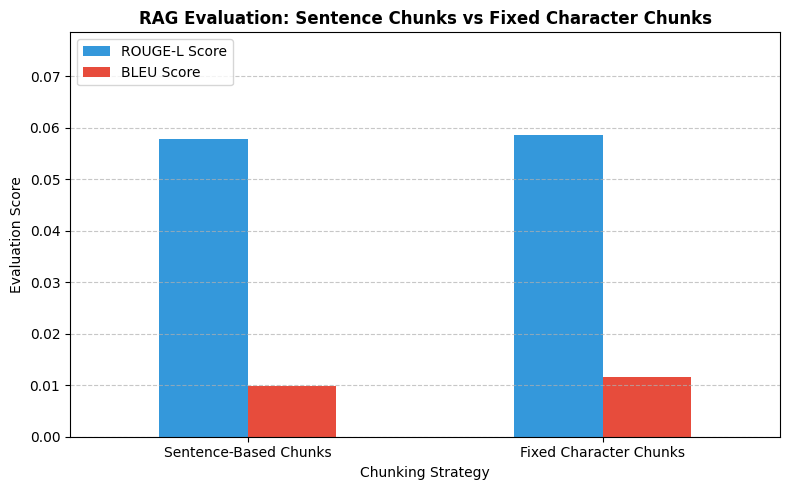

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# RESULTS COMPARISON & VISUALIZATION

#Exact scores from the output logs
sentence_rouge = 0.0577
sentence_bleu = 0.0099

fixed_rouge = 0.0585
fixed_bleu = 0.0115

# Creating the comparison dataframe
data = {
    "Methodology": ["Sentence-Based Chunks", "Fixed Character Chunks"],
    "ROUGE-L Score": [sentence_rouge, fixed_rouge],
    "BLEU Score": [sentence_bleu, fixed_bleu]
}
df = pd.DataFrame(data)

print("--- FINAL RAG PERFORMANCE MATRIX ---")
print(df.to_string(index=False))
print("-" * 36)

# Plotting the comparison chart for the report
fig, ax = plt.subplots(figsize=(8, 5))
df.set_index("Methodology").plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"])

plt.title("RAG Evaluation: Sentence Chunks vs Fixed Character Chunks", fontsize=12, fontweight='bold')
plt.ylabel("Evaluation Score", fontsize=10)
plt.xlabel("Chunking Strategy", fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(sentence_rouge, fixed_rouge) + 0.02)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()